In [ ]:
import pandas as pd
import numpy as np
data=pd.DataFrame(
    {
    "customer_name":["mohan","harsha","vardha","shannu"],
    "internet speed":[1,12,4,20],
    "payment_failure":[10,2,6,0],
    "delivery_chages":[542,235,140,100],
    "purchase_completed":[0,1,0,1]
    }
)
print("Total Abandament: ",(data["purchase_completed"].value_counts()))
print("Internet Diagnosis: ",(data["internet speed"].values>=1))
print("Payment Diagnosis: ",(data["payment_failure"].values==0))
print("Delivery Diagnosis: ",(data["delivery_chages"].value_counts()))

#root cause analysis
print("Poor Internet: ",data["internet speed"].value_counts())
print("Poor Payment: ",data["payment_failure"].value_counts())
print("Poor Delivery: ",data["delivery_chages"].value_counts())



Total Abandament:  purchase_completed
0    2
1    2
Name: count, dtype: int64
Internet Diagnosis:  [ True  True  True  True]
Payment Diagnosis:  [False False False  True]
Delivery Diagnosis:  delivery_chages
542    1
235    1
140    1
100    1
Name: count, dtype: int64
Poor Internet:  internet speed
1     1
12    1
4     1
20    1
Name: count, dtype: int64
Poor Payment:  payment_failure
10    1
2     1
6     1
0     1
Name: count, dtype: int64
Poor Delivery:  delivery_chages
542    1
235    1
140    1
100    1
Name: count, dtype: int64


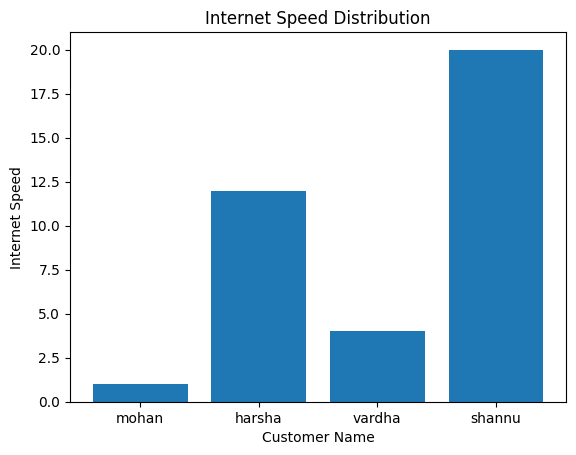

In [ ]:
#plotting
import matplotlib.pyplot as plt
plt.bar(data['customer_name'],data['internet speed'])
plt.title("Internet Speed Distribution")
plt.xlabel("Customer Name")
plt.ylabel("Internet Speed")
plt.show()

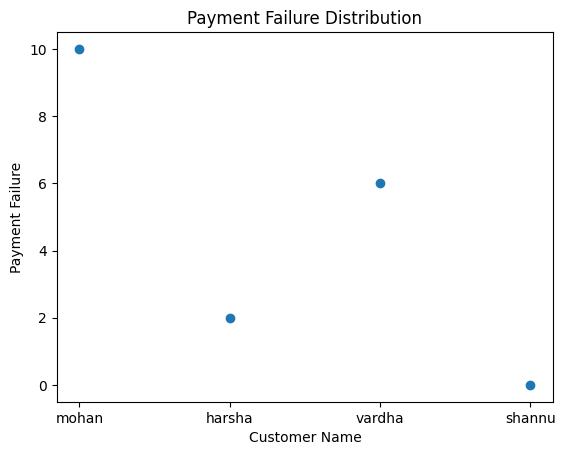

In [ ]:
#scatter plot
plt.scatter(data['customer_name'],data['payment_failure'])
plt.title("Payment Failure Distribution")
plt.xlabel("Customer Name")
plt.ylabel("Payment Failure")
plt.show()

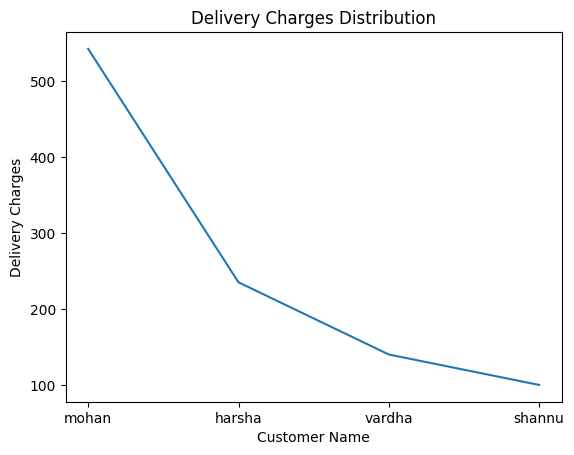

In [ ]:
#line plot
plt.plot(data['customer_name'],data['delivery_chages'])
plt.title("Delivery Charges Distribution")
plt.xlabel("Customer Name")
plt.ylabel("Delivery Charges")
plt.show()

In [ ]:
data=pd.read_csv("/content/ecommerce_sales_34500.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [ ]:
data['High_Price'] = data['price'] > 5000

data['High_Discount'] = data['discount'] > 30

data['Late_Delivery'] = data['delivery_time_days'] > 7

data['High_Shipping_Cost'] = data['shipping_cost'] > 500

data['Returned_Product'] = data['returned'] == 'Yes'

data['Low_Profit'] = data['profit_margin'] < 10


print("\nDiagnosis Table:\n")

print(data[[
    'order_id',
    'category',
    'price',
    'discount',
    'delivery_time_days',
    'shipping_cost',
    'profit_margin',
    'returned',
    'High_Price',
    'High_Discount',
    'Late_Delivery',
    'High_Shipping_Cost',
    'Low_Profit'
]])

returned_orders = data[data['returned'] == 'Yes']

print("\nROOT CAUSE ANALYSIS\n")

print("Returned orders count:",
      len(returned_orders))

print(f"\nProducts with high price:{returned_orders['High_Price'].sum()}")
print(f"\nProducts with heavy discount:{returned_orders['High_Discount'].sum()}")
print(f"\nProducts with late delivery:{returned_orders['Late_Delivery'].sum()}")
print(f"\nProducts with high shipping cost:{returned_orders['High_Shipping_Cost'].sum()}")
print(f"\nProducts with low profit:{returned_orders['Low_Profit'].sum()}")


Diagnosis Table:

      order_id     category   price  discount  delivery_time_days  \
0      O100000         Home  164.08      0.15                   4   
1      O100001      Grocery   24.73      0.00                   6   
2      O100002  Electronics  175.58      0.05                   4   
3      O100003  Electronics   63.67      0.00                   6   
4      O100004         Home   16.33      0.15                   6   
...        ...          ...     ...       ...                 ...   
34495  O134495      Fashion   10.44      0.20                   3   
34496  O134496       Beauty    4.79      0.10                   6   
34497  O134497  Electronics  323.64      0.00                   6   
34498  O134498         Home   23.09      0.05                   6   
34499  O134499         Home   76.84      0.00                   6   

       shipping_cost  profit_margin returned  High_Price  High_Discount  \
0               7.88          31.17       No       False          False   
1 

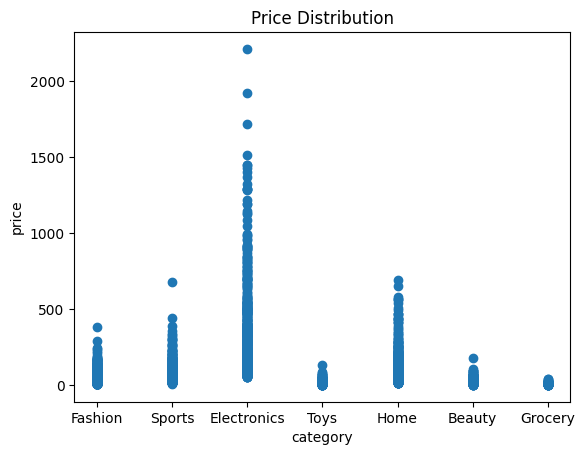

In [ ]:
#plotting
plt.scatter(returned_orders['category'],returned_orders['price'])
plt.title("Price Distribution")
plt.xlabel("category")
plt.ylabel("price")
plt.show()
#

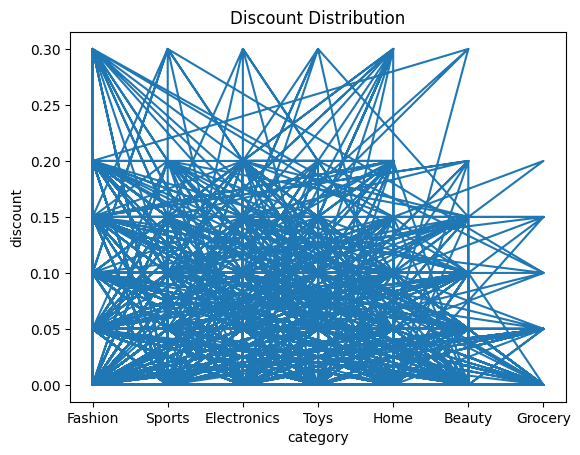

In [ ]:
#line plotting
plt.plot(returned_orders['category'],returned_orders['discount'])
plt.title("Discount Distribution")
plt.xlabel("category")
plt.ylabel("discount")
plt.show()

Initial Data:
   Water_consumption  Days
0                200     1
1                190     2
2                211     3
3                212     4
4                213     5

Average water consumption: 205.20 liters

Daily Change:
   Water_consumption  Days  Difference
0                200     1         NaN
1                190     2       -10.0
2                211     3        21.0
3                212     4         1.0
4                213     5         1.0

Average daily increase in water consumption: 3.25 liters

Water shortage starts on Day 3
Shortage amount on that day: 6 liters


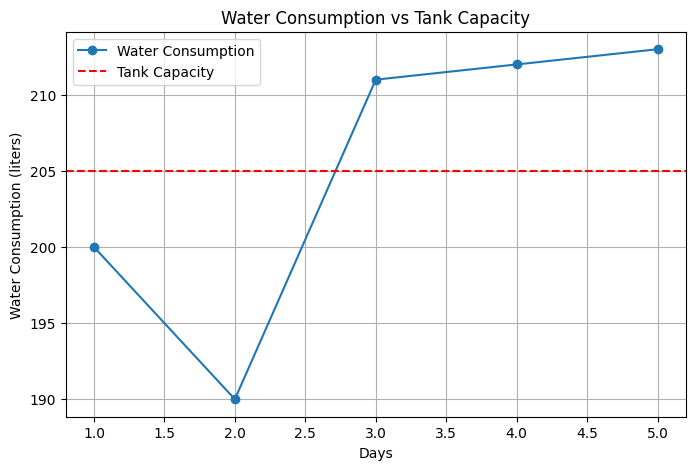

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.DataFrame(
    {
        "Water_consumption": [200, 190, 211, 212, 213],
        "Days": [1, 2, 3, 4, 5]
    }
)

print("Initial Data:")
print(data)

avg = data['Water_consumption'].mean()
print(f"\nAverage water consumption: {avg:.2f} liters")

data['Difference'] = data['Water_consumption'].diff()

print("\nDaily Change:")
print(data)

avg_increase = data['Difference'].mean()
print(f"\nAverage daily increase in water consumption: {avg_increase:.2f} liters")

tank_capacity = 205

data['Shortage'] = data['Water_consumption'] > tank_capacity

shortage_days = data[data['Shortage']]

if not shortage_days.empty:
    first_shortage_day = shortage_days.iloc[0]['Days']
    shortage_amount = shortage_days.iloc[0]['Water_consumption'] - tank_capacity

    print(f"\nWater shortage starts on Day {int(first_shortage_day)}")
    print(f"Shortage amount on that day: {shortage_amount} liters")
else:
    print("\nNo water shortage detected.")

plt.figure(figsize=(8,5))
plt.plot(data['Days'], data['Water_consumption'],
         marker='o', label='Water Consumption')
plt.axhline(y=tank_capacity, color='r',
            linestyle='--', label='Tank Capacity')
plt.xlabel("Days")
plt.ylabel("Water Consumption (liters)")
plt.title("Water Consumption vs Tank Capacity")
plt.legend()
plt.grid(True)

plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
       Temperature     Humidity   Wind_Speed  Cloud_Cover     Pressure
count  2500.000000  2500.000000  2500.000000  2500.000000  2500.000000
mean     22.581725    64.347094     9.906255    49.658104  1014.312336
std       7.326996    19.954739     5.780316    29.123104    20.196433
min      10.001842    30.005071     0.009819     0.015038   980.014486
25%      16.359398    47.339815     4.761909    23.900016   996.938630
50%      22.536448    63.920797     9.908572    49.488284  1013.433035
75%    

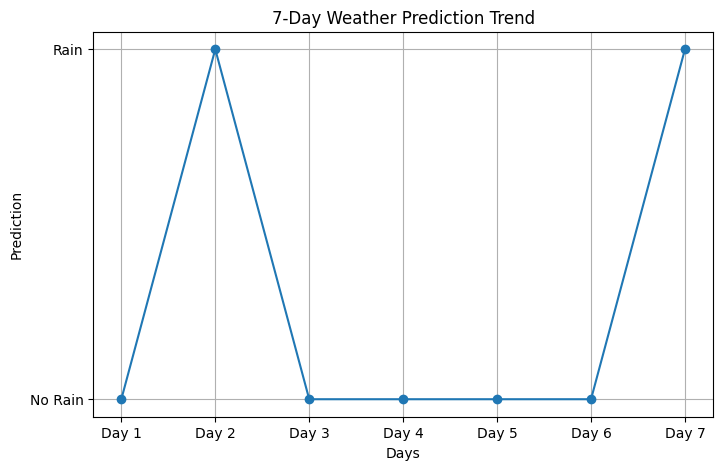

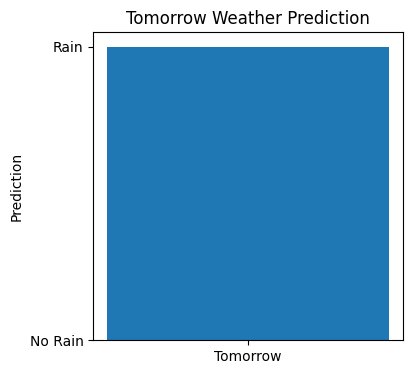

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/weather_forecast_data.csv')
df.info()
print(df.describe())
avg_humidity = df['Humidity'].mean()
avg_cloud = df['Cloud_Cover'].mean()

days = []
predictions = []

for i, row in enumerate(df.tail(7).itertuples(), start=1):

    humidity = row.Humidity
    cloud_cover = row.Cloud_Cover

    if humidity > avg_humidity and cloud_cover > avg_cloud:
        pred = "Rain"
        value = 1
    else:
        pred = "No Rain"
        value = 0

    days.append(f"Day {i}")
    predictions.append(value)
    tomorrow_humidity = df['Humidity'].iloc[-1]
tomorrow_cloud = df['Cloud_Cover'].iloc[-1]

print("\nTomorrow's Data")
print("Humidity:", tomorrow_humidity)
print("Cloud Cover:", tomorrow_cloud)

# Prediction
if tomorrow_humidity > avg_humidity and tomorrow_cloud > avg_cloud:
    print("\nTomorrow Prediction: Rain")
else:
    print("\nTomorrow Prediction: No Rain")

plt.figure(figsize=(8,5))
plt.plot(days, predictions, marker='o')

plt.title("7-Day Weather Prediction Trend")
plt.xlabel("Days")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])

plt.grid(True)
plt.show()
prediction = 1 if (tomorrow_humidity > avg_humidity and tomorrow_cloud > avg_cloud) else 0

plt.figure(figsize=(4,4))
plt.bar(["Tomorrow"], [prediction])

plt.title("Tomorrow Weather Prediction")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])

plt.show()

Initial Data:
   Days  Petrol_Price
0     1           100
1     2           103
2     3            96
3     4           105
4     5            98
5     6           107
6     7           108

Average petrol price: ₹102.43

Daily Price Change:
   Days  Petrol_Price  Difference
0     1           100         NaN
1     2           103         3.0
2     3            96        -7.0
3     4           105         9.0
4     5            98        -7.0
5     6           107         9.0
6     7           108         1.0

Average daily increase in petrol price: ₹1.33

Predicted Petrol Prices:
   Future_Days  Predicted_Price
0            8       107.285714
1            9       108.500000
2           10       109.714286
3           11       110.928571
4           12       112.142857


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


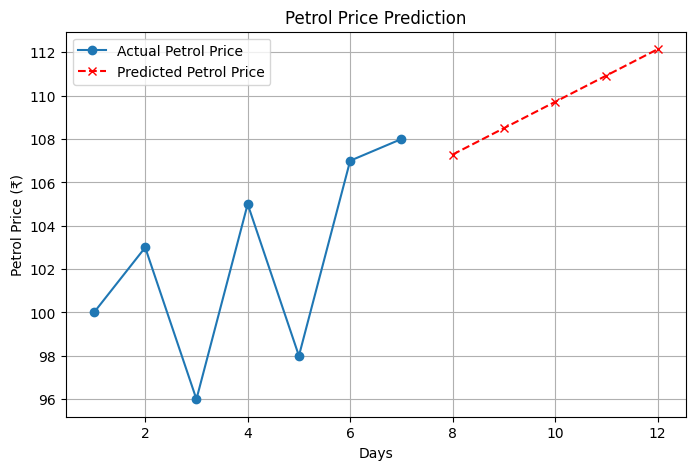

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample petrol price data
data = pd.DataFrame(
    {
        "Days": [1, 2, 3, 4, 5, 6, 7],
        "Petrol_Price": [100, 103, 96, 105, 98, 107, 108]
    }
)

print("Initial Data:")
print(data)

# Calculate average petrol price
avg_price = data['Petrol_Price'].mean()
print(f"\nAverage petrol price: ₹{avg_price:.2f}")

# Calculate daily change
data['Difference'] = data['Petrol_Price'].diff()

print("\nDaily Price Change:")
print(data)

avg_increase = data['Difference'].mean()
print(f"\nAverage daily increase in petrol price: ₹{avg_increase:.2f}")

# Machine Learning Model for Prediction
X = data[['Days']]
y = data['Petrol_Price']

model = LinearRegression()
model.fit(X, y)

# Predict petrol price for next 5 days
future_days = np.array([8, 9, 10, 11, 12]).reshape(-1, 1)
predicted_prices = model.predict(future_days)

prediction_data = pd.DataFrame(
    {
        "Future_Days": future_days.flatten(),
        "Predicted_Price": predicted_prices
    }
)

print("\nPredicted Petrol Prices:")
print(prediction_data)

# Plotting
plt.figure(figsize=(8,5))

# Original data
plt.plot(data['Days'], data['Petrol_Price'],
         marker='o', label='Actual Petrol Price')

# Predicted data
plt.plot(prediction_data['Future_Days'],
         prediction_data['Predicted_Price'],
         marker='x', linestyle='--',
         color='red', label='Predicted Petrol Price')

plt.xlabel("Days")
plt.ylabel("Petrol Price (₹)")
plt.title("Petrol Price Prediction")
plt.legend()
plt.grid(True)

plt.show()

Initial Data:
   Days  Petrol_Price
0     1           100
1     2           103
2     3            96
3     4           105
4     5            98
5     6           107
6     7           108

Average petrol price: ₹102.43

Daily Price Change:
   Days  Petrol_Price  Difference
0     1           100         NaN
1     2           103         3.0
2     3            96        -7.0
3     4           105         9.0
4     5            98        -7.0
5     6           107         9.0
6     7           108         1.0

Average daily increase: ₹1.33

Predicted Petrol Prices:
   Future_Days  Predicted_Price
0            8       109.333333
1            9       110.666667
2           10       112.000000
3           11       113.333333
4           12       114.666667


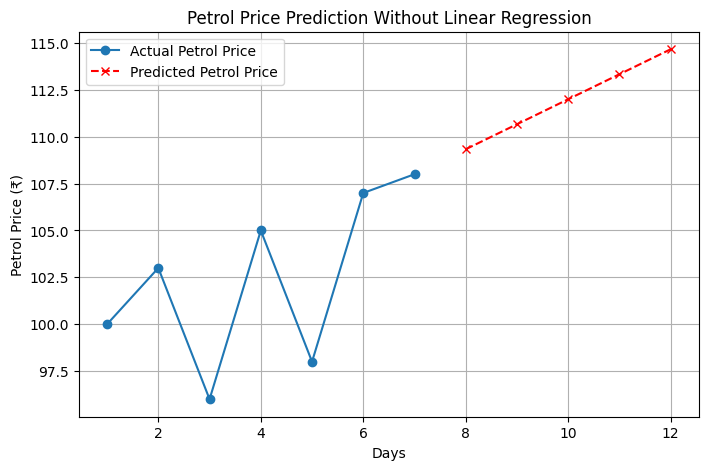

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample petrol price data
data = pd.DataFrame(
    {
        "Days": [1, 2, 3, 4, 5, 6, 7],
        "Petrol_Price": [100, 103, 96, 105, 98, 107, 108]
    }
)

print("Initial Data:")
print(data)

# Calculate average petrol price
avg_price = data['Petrol_Price'].mean()
print(f"\nAverage petrol price: ₹{avg_price:.2f}")

# Calculate daily price change
data['Difference'] = data['Petrol_Price'].diff()

print("\nDaily Price Change:")
print(data)

# Average daily increase
avg_increase = data['Difference'].mean()
print(f"\nAverage daily increase: ₹{avg_increase:.2f}")

# Predict next 5 days using average increase
last_price = data['Petrol_Price'].iloc[-1]

future_days = []
predicted_prices = []

for i in range(1, 6):
    next_day = data['Days'].iloc[-1] + i
    next_price = last_price + (avg_increase * i)

    future_days.append(next_day)
    predicted_prices.append(next_price)

# Prediction DataFrame
prediction_data = pd.DataFrame(
    {
        "Future_Days": future_days,
        "Predicted_Price": predicted_prices
    }
)

print("\nPredicted Petrol Prices:")
print(prediction_data)

# Plotting
plt.figure(figsize=(8,5))

# Actual prices
plt.plot(
    data['Days'],
    data['Petrol_Price'],
    marker='o',
    label='Actual Petrol Price'
)

# Predicted prices
plt.plot(
    prediction_data['Future_Days'],
    prediction_data['Predicted_Price'],
    marker='x',
    linestyle='--',
    color='red',
    label='Predicted Petrol Price'
)

plt.xlabel("Days")
plt.ylabel("Petrol Price (₹)")
plt.title("Petrol Price Prediction Without Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#smart hospital bed allocation system
data = pd.DataFrame(
    {
        "Patient_Name": ["harsha","mohan","shannu","vardhan"],
        "Age": [25, 30, 35, 40],
        "Condition":["Critical","Serious","Serious","stable"],
        "Oxygen Level": [95, 90, 85, 60],
        #"Avaiable_Beds": ["ICU-1","ICU-2","ICU-3","general1"]
    }
)

print("Initial Data:")
print(data)




Initial Data:
  Patient_Name  Age Condition  Oxygen Level
0       harsha   25  Critical            95
1        mohan   30   Serious            90
2       shannu   35   Serious            85
3      vardhan   40    stable            60


In [40]:
total_beds = 3

def calculate_priority(row):

    if row["Condition"] == "Critical":
        condition_weight = 50
    elif row["Condition"] == "Serious":
        condition_weight = 30
    else:
        condition_weight = 10

    if row["Age"] > 60:
        age_factor = 20
    elif row["Age"] >= 40:
        age_factor = 10
    else:
        age_factor = 5

    score = (100 - row["Oxygen Level"]) + condition_weight + age_factor

    return score

data["Priority Score"] = data.apply(calculate_priority, axis=1)

data = data.sort_values(by="Priority Score", ascending=False)

data["Bed Status"] = "No Bed Available"

data.iloc[:total_beds, data.columns.get_loc("Bed Status")] = "Bed Allocated"

def prescription(row):

    if row["Condition"] == "Critical":
        return "Assign Ventilator"

    elif row["Condition"] == "Serious":
        return "Provide Oxygen"

    else:
        return "Tablets"

data["Prescription"] = data.apply(prescription, axis=1)

print("\nFinal Hospital Allocation Report:\n")
print(data)

no_bed_patients = data[data["Bed Status"] == "No Bed Available"]

print("\nPatients Without Beds:\n")

if len(no_bed_patients) > 0:
    print(no_bed_patients[[
        "Patient_Name",
        "Condition",
        "Priority Score"
    ]])
else:
    print("All patients received beds.")


Final Hospital Allocation Report:

  Patient_Name  Age Condition  Oxygen Level  Priority Score        Bed Status  \
0       harsha   25  Critical            95              60     Bed Allocated   
3      vardhan   40    stable            60              60     Bed Allocated   
2       shannu   35   Serious            85              50     Bed Allocated   
1        mohan   30   Serious            90              45  No Bed Available   

        Prescription  
0  Assign Ventilator  
3            Tablets  
2     Provide Oxygen  
1     Provide Oxygen  

Patients Without Beds:

  Patient_Name Condition  Priority Score
1        mohan   Serious              45


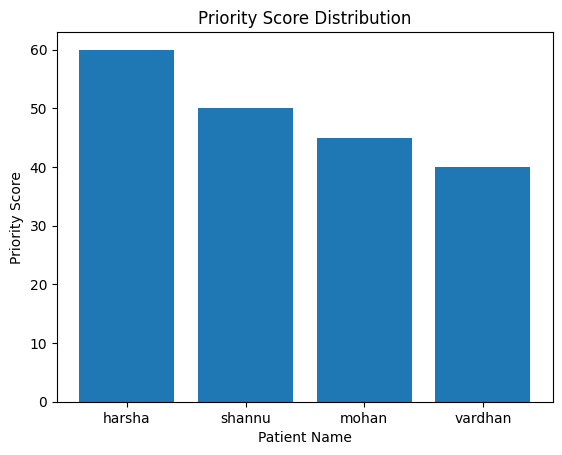

In [32]:
#plotting
plt.bar(data['Patient_Name'],data['Priority Score'])
plt.title("Priority Score Distribution")
plt.xlabel("Patient Name")
plt.ylabel("Priority Score")
plt.show()